<a href="https://colab.research.google.com/github/ealeongomez/Data/blob/main/Linear_Regression_Machine_Learning_Methods_1_WindSpeed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/ealeongomez/Data

Cloning into 'Data'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 12 (delta 3), reused 0 (delta 0), pack-reused 0
Unpacking objects: 100% (12/12), done.


In [2]:
# Básicos 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import os

# Pre-procesamiento 
from sklearn.preprocessing import StandardScaler

# Reducción de dimensiones 
from sklearn.decomposition import PCA

# Selección de los conjuntos de entrenamiento y validación 
from sklearn.model_selection import train_test_split, GridSearchCV

# Regresión lineal 
from sklearn.kernel_ridge import KernelRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso

# Clasificación 
from sklearn.neighbors import KNeighborsClassifier

# Error 
from sklearn.metrics import mean_squared_error 

# Etapas del procesamiento 
from sklearn.pipeline import Pipeline

# Pretty print
from pprint import pprint

In [3]:
cd Data/

/content/Data


In [4]:
ls

PuertoBolivar.csv


#**Function**

In [5]:
def Serie_to_matriz(X_input, window):
    """ Input: 
            X_input: time serie (array column)
            window=10
        Output:
            X_output: window matrix ()
            y_output
    """
    X_output = np.zeros([len(X_input)-window,window])
    for i in range(len(X_input)-window):
        X_output[i,:] = X_input[i:i+5].T 
    
    y_output = X_input[window:]
    
    return X_output, y_output

#**Read Data**

In [6]:
df = pd.read_csv("PuertoBolivar.csv")
df['date'] = df.apply(lambda row: str(int(row.year)) +"-"+ str(int(row.month)) +"-"+ str(int(row.day)), axis=1)
df.set_index('date', inplace=True)
df.index = pd.to_datetime(df.index)

del df['year'], df['month'], df['day']

print(df.head())
print("Número total de datos: {} ".format(len(df)*24))


              1    2    3    4    5    6  ...   19   20   21   22   23   24
date                                      ...                              
1996-01-01  5.6  3.9  3.9  4.2  5.8  4.2  ...  7.8  8.6  8.9  6.9  6.7  4.2
1996-01-02  2.8  1.5  1.9  1.9  2.5  3.6  ...  6.7  6.7  6.4  5.8  7.2  8.1
1996-01-03  6.1  5.3  4.2  4.3  4.7  4.7  ...  9.2  8.3  8.3  7.5  6.4  6.7
1996-01-04  5.8  5.3  5.3  4.7  5.0  3.9  ...  8.9  7.8  8.1  6.7  6.7  5.8
1996-01-05  5.8  5.6  6.7  5.7  6.8  7.2  ...  8.9  8.6  7.8  8.6  8.3  8.3

[5 rows x 24 columns]
Número total de datos: 151248 


Debido a que la base de datos presenta NaN, cambianos lo valores de los datos por -1 para identificar las zonas de la series de tiempo donde tenemos datos faltantes. Cabe resaltar que las velocidades del viento nunca son negativas

In [7]:
df = df.replace(np.nan, -1)

In [8]:
timeSerie = df.stack()
print("Tamaño de la serie de tiempo {}".format(len(timeSerie)))
print("Número de mustras con valores vacíos {}".format(timeSerie.value_counts()[-1]))

Tamaño de la serie de tiempo 151248
Número de mustras con valores vacíos 14338


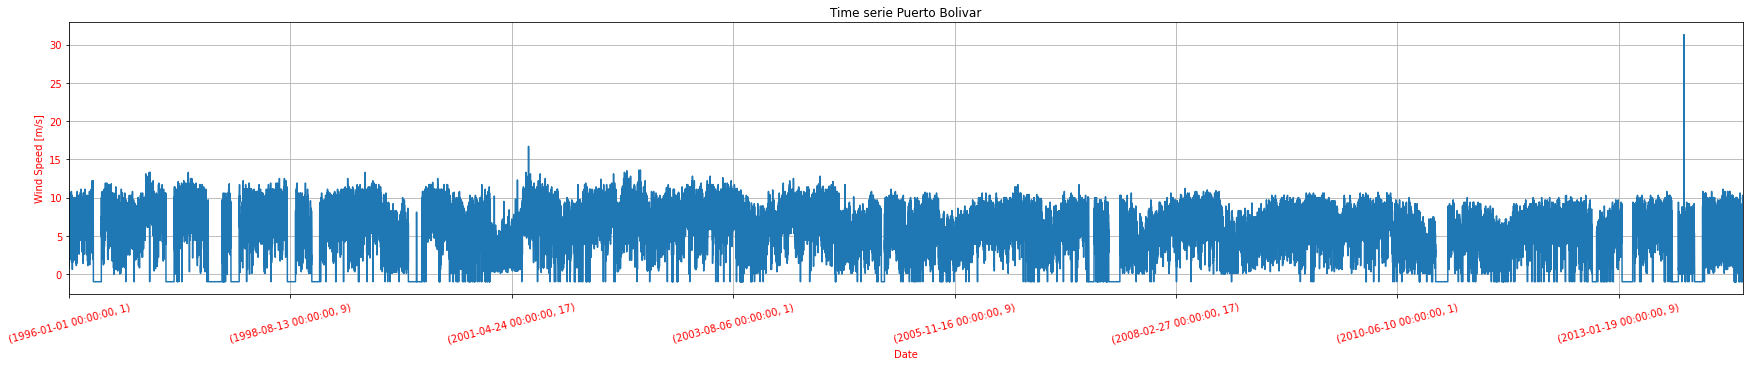

In [9]:
# Ploter el conjunto de datos 
plt.figure(figsize=(30,5))
timeSerie.plot(subplots=True)
plt.xlim(0,len(timeSerie))
plt.xticks(c='r', rotation=15); plt.xlabel('Date', c='r')
plt.yticks(c='r'); plt.ylabel('Wind Speed [m/s]',c='r')
plt.title('Time serie Puerto Bolivar')
plt.grid(True)

#**Pre-proocessing**

Número de datos: 6192


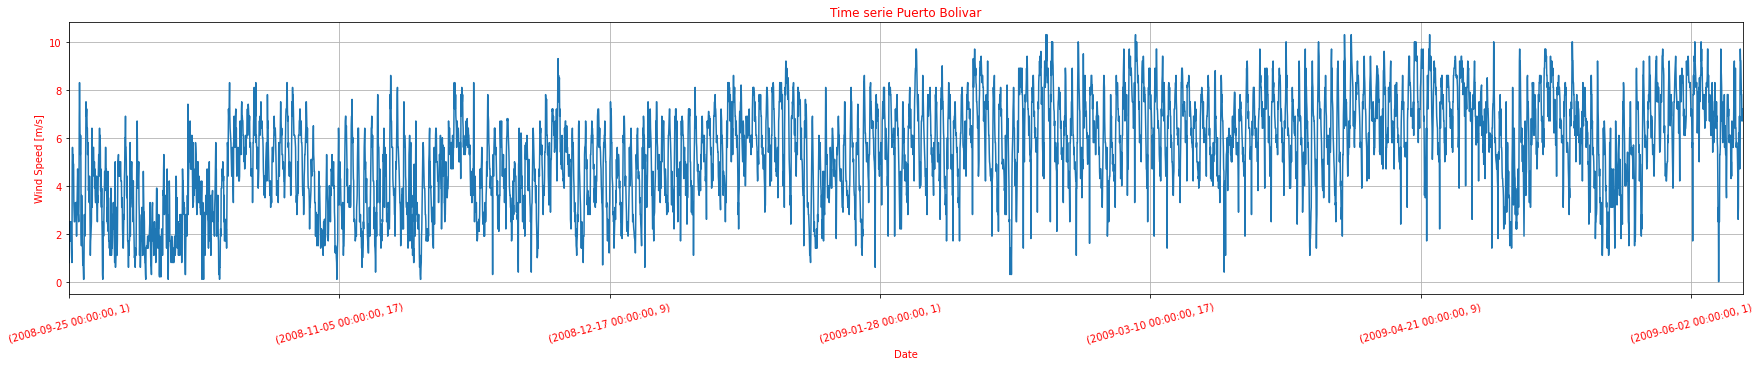

In [10]:
# Fragmento de serie de tiempo continua sin valores valore NaN
wind = timeSerie.loc['2008-9-25':'2009-6-9']

plt.figure(figsize=(30,5))
wind.plot(subplots=True)
plt.xlim(0,len(wind))
plt.xticks(c='r', rotation=15); plt.xlabel('Date', c='r')
plt.yticks(c='r'); plt.ylabel('Wind Speed [m/s]',c='r')
plt.title('Time serie Puerto Bolivar',c='r')
plt.grid(True)

print("Número de datos: {}".format(len(wind)))

X_input = np.array(wind)
time = np.arange(0, len(X_input),1)


In [11]:
X__, y__ = Serie_to_matriz(X_input, window=5) 

X_, X_test, y_, y_test = train_test_split(X__, y__, test_size=0.20, random_state=42)

X_.shape, y_.shape, X_test.shape, y_test.shape

((4949, 5), (4949,), (1238, 5), (1238,))

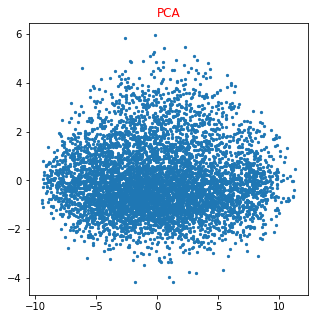

In [12]:
# Analisis exploratorio de los datos
pca = PCA(n_components = 2)
tranformed_pca = pca.fit_transform(X__)

plt.figure(figsize=(5, 5))
plt.title("PCA", c='r')
plt.scatter(tranformed_pca[:,0], tranformed_pca[:,1], s=5)
plt.show() 

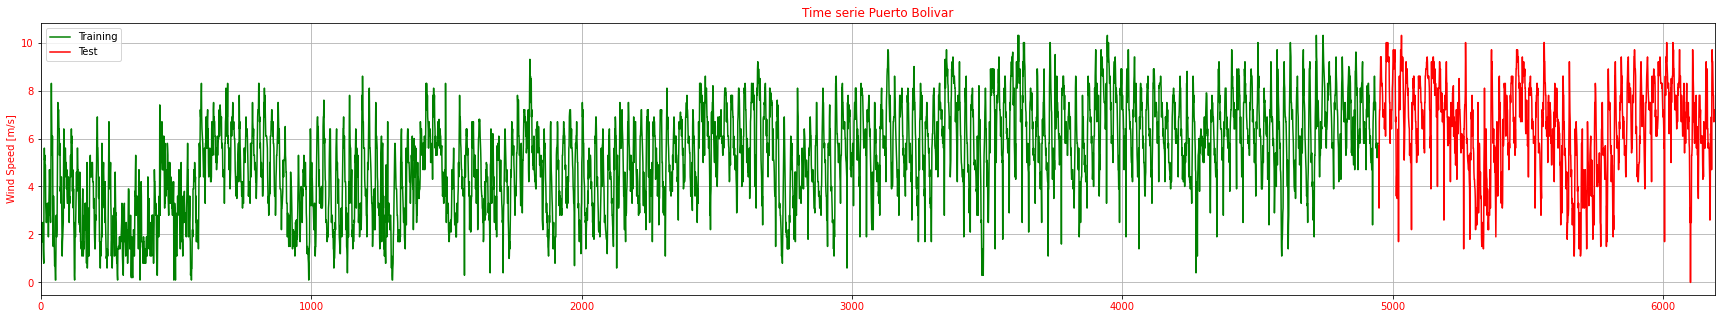

In [13]:
# Ploter el conjunto de datos 
plt.figure(figsize=(30,5))
plt.plot(time[0:X_.shape[0]], X_input[0:X_.shape[0]], 'g', label= 'Training')
plt.plot(time[X_.shape[0]:], X_input[X_.shape[0]:], 'r', label= 'Test')
plt.title('Time serie Puerto Bolivar',c='r')
plt.xticks(c='r')
plt.yticks(c='r'); plt.ylabel('Wind Speed [m/s]',c='r')
plt.xlim(0, X_input.shape[0])
plt.legend()
plt.grid(True)
plt.show()

#**Machine Learning Models**

1. Kernel Ridge:

$$Cost function = \frac{1}{2} \sum (y_{i} - w^\top x_{i})^{2} + \frac{1}{2}\lambda||w||^{2}$$


$$w^* = \left( \lambda I + \sum x_{i}x_{i}^\top\right)^{-1} \left(\sum y_{i}x_{i}\right)$$

$$ w = \left(  \alpha I + \Phi \Phi^\top \right)^{-1} \left( \Phi y \right) $$  
$$\alpha = \sum \alpha \Phi (x_{i})$$

La salida del modelo estara dada por:

$$ y = w \Phi (x) = y\left( \Phi \phi + \alpha I_{n} \right)^{-1}\Phi\Phi(x) $$
$$ y = y\left( K + \lambda I_{n} \right)^{-1}k(x)$$


2. KNeighborsRegressor:


In [14]:
# Caracteristicos de los modelos a probar 
"""
    1. 'scaler': Estandarizar cada atriuto columna de xtrain centrada en 0 y var = 1
    2. 'reg': Clasificador 
    3. 'scaler': Estandarizar cada atriuto columna de xtrain centrada en 0 y var = 1
    4. 'rep': reducción de dimensiones
    5. 'reg': Pueden utilizar clase generada tsne_map()
"""

models = [
            [('scaler', StandardScaler()), 
             ('reg',  KernelRidge(kernel = 'rbf'))
            ],  
            [('scaler', StandardScaler()), 
             ('rep', PCA()),
             ('reg', KNeighborsRegressor())]
        ]   
            
model_names = ['NorSC-KRRBF','NorSC-PCA-KNN']            

# Parametros de búsqueda por malla
""" 
    Parametros n_neighbors debe ser siempre un int       
""" 

parameters =[{'reg__gamma':[1e-3,1e-2,1e-1,1,10,100],
              'reg__alpha':[1e-3,1e-2,1e-1,1,10,100]
              },
             {'reg__n_neighbors': [1,3,5], 
              'rep__n_components':[0.5,0.75,0.9]}
             ]

In [15]:
# Número de particiones para la cross-validación
iterations = 10     
# Matriz para guardar el mejor modelo de predicción
mse = np.zeros((iterations,len(models)))
# Mejor predictor y sus hiperparametros
best_estimators = iterations*[None]
best_hyperparameters = iterations*[None]

# Recorrer todos los posibles modelos 
# i: Variaciones de los hiper-parámetros              
for i in range(iterations):          
    # Selección de los conjunto de entrenamiento y   validación
    X_train, X_valid, y_train, y_valid = train_test_split(X_, y_, test_size=0.3)
    
    # Guardar mejor predictor y sus hiperparametros
    list_est = [] 
    list_hyperparameters = [] 

    # Recorrer todos las posibles variables (hiper-parámetros)  
    # j: posibles modelos 
    for j in range(len(models)):
        
        # Seleccion de modelo y parámetros
        method = models[j]
        parameter = parameters[j]

        print("Model {Nmodel} of {Smodel}. Iteration {Niteration} of {Siteration}".format(Nmodel=j,Smodel=len(models),Niteration=i,Siteration=iterations))
        
        grid_search = GridSearchCV(Pipeline(method), 
                                   parameter,
                                   cv=5,
                                   verbose=5,
                                   n_jobs=-1,
                                   scoring='neg_mean_absolute_error')
        
        # Generar modelo
        grid_search.fit(X_train, y_train)
        # Estimar salida conjunto de valid
        y_pred = grid_search.best_estimator_.predict(X_valid)
        # Guardar Mean Suqre Error ()            
        mse[i,j] = mean_squared_error(y_valid, y_pred)
        
        list_est.append(grid_search.best_estimator_)
        list_hyperparameters.append(grid_search.best_params_)

    # Guardar mejores modelos y sus hiperparametros
    best_estimators[i] = list_est 
    best_hyperparameters[i] = list_hyperparameters  

results = { 
        'MSE': mse,
        'best_models':best_estimators,
        'best_parameters':best_hyperparameters
        }


Model 0 of 2. Iteration 0 of 10
Fitting 5 folds for each of 36 candidates, totalling 180 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    8.2s
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:   38.0s
[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 180 out of 180 | elapsed:  1.7min finished


Model 1 of 2. Iteration 0 of 10
Fitting 5 folds for each of 9 candidates, totalling 45 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  45 out of  45 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Model 0 of 2. Iteration 1 of 10
Fitting 5 folds for each of 36 candidates, totalling 180 fits


...

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  45 out of  45 | elapsed:    0.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.


Model 0 of 2. Iteration 9 of 10
Fitting 5 folds for each of 36 candidates, totalling 180 fits


[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done  68 tasks      | elapsed:   33.2s
[Parallel(n_jobs=-1)]: Done 158 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done 180 out of 180 | elapsed:  1.5min finished


Model 1 of 2. Iteration 9 of 10
Fitting 5 folds for each of 9 candidates, totalling 45 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  42 out of  45 | elapsed:    0.3s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  45 out of  45 | elapsed:    0.3s finished


In [16]:
parameters_matriz = []
best_hyperparameters_final = []
for r in range(len(models)):
  hyperparameters_r = np.zeros((iterations, len(best_hyperparameters[0][r])))
  for i in range(iterations):
    for j in range(len(best_hyperparameters[0][r])):
      hyperparameters_r[i,j] = best_hyperparameters[i][r].get(list(best_hyperparameters[i][r].keys())[j])

  #  Guardar matriz de parámetros 
  parameters_matriz.append(hyperparameters_r)
  
  # Guardar mediana de los hiper-parámetros
  #np.median(hyperparameters_r[:,0]) , np.median(hyperparameters_r[:,1])]
  best_hyperparameters_final.append([np.median(hyperparameters_r[:,0]),np.median(hyperparameters_r[:,1])]) 

#print("Mejores parámetros para cada uno de los modelos:")
print(best_hyperparameters_final) 

[[0.1, 0.1], [5.0, 0.9]]


In [17]:
# Entrenamiento de los modelos con los mejores hiperparámetros 
regression = []
for r in range(len(models)):
  print("Model: ", r, " ", best_hyperparameters_final[r])
  model_f = Pipeline(models[r])
  paramsf = parameters[r]
  label_parameters = list(parameters[r].keys())
  for i in range(len(label_parameters)):
    if label_parameters[i] == 'reg__n_neighbors':
      paramsf[label_parameters[i]] = int(best_hyperparameters_final[r][i])
    else:  
      paramsf[label_parameters[i]] = best_hyperparameters_final[r][i]

  model_f.set_params(**paramsf)
  model_f.fit(X_, y_)

  regression.append(model_f.predict(X_test))

Model:  0   [0.1, 0.1]
Model:  1   [5.0, 0.9]


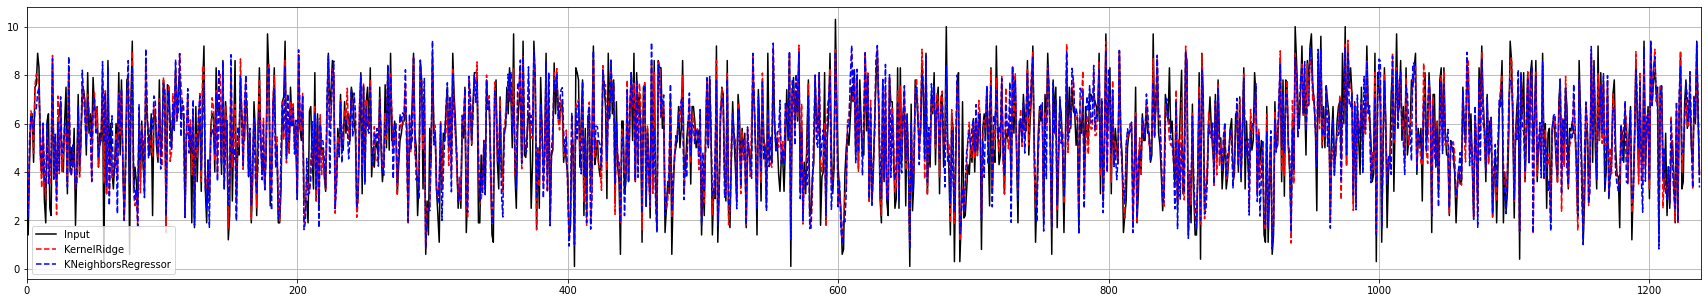

In [21]:
# Resultados (Plotter 1)
plt.figure(figsize=(30,5))
plt.plot(y_test,label='Input', c='k')
plt.plot(regression[0],label='KernelRidge', c='r',  linestyle='--')
plt.plot(regression[1],label='KNeighborsRegressor', c='b',  linestyle='--')
plt.xlim(0,len(y_test))
plt.grid()
plt.legend()
plt.show()